In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import cv2
import os
import tqdm
import numpy as np
from torch.utils.data import DataLoader,Dataset
from PIL import Image
import torchvision.transforms.functional as TF

In [2]:
torch.cuda.is_available()

True

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
import os
import cv2

train_folder_path_x = "/kaggle/input/cv-project-data/low_resolution"
train_folder_path_y = "/kaggle/input/cv-project-data/high_resolution"
data_tuple = []

class MyDataLoader():
    def make_training_data(self):
        for f in os.listdir(train_folder_path_x):
            image_path_x = os.path.join(train_folder_path_x, f)
            image_path_y = os.path.join(train_folder_path_y, f)

            image_x = cv2.imread(image_path_x)

            image_y = cv2.imread(image_path_y)
            data_tuple.append((image_x,image_y))
                
dataLoader = MyDataLoader()
dataLoader.make_training_data()

In [5]:
from sklearn.model_selection import train_test_split
train_tuple, test_tuple = train_test_split(data_tuple, test_size=0.1, random_state=42)

In [6]:
print(len(train_tuple))
print((train_tuple[20][0]).shape)
print((train_tuple[20][1]).shape)

810
(128, 128, 3)
(512, 512, 3)


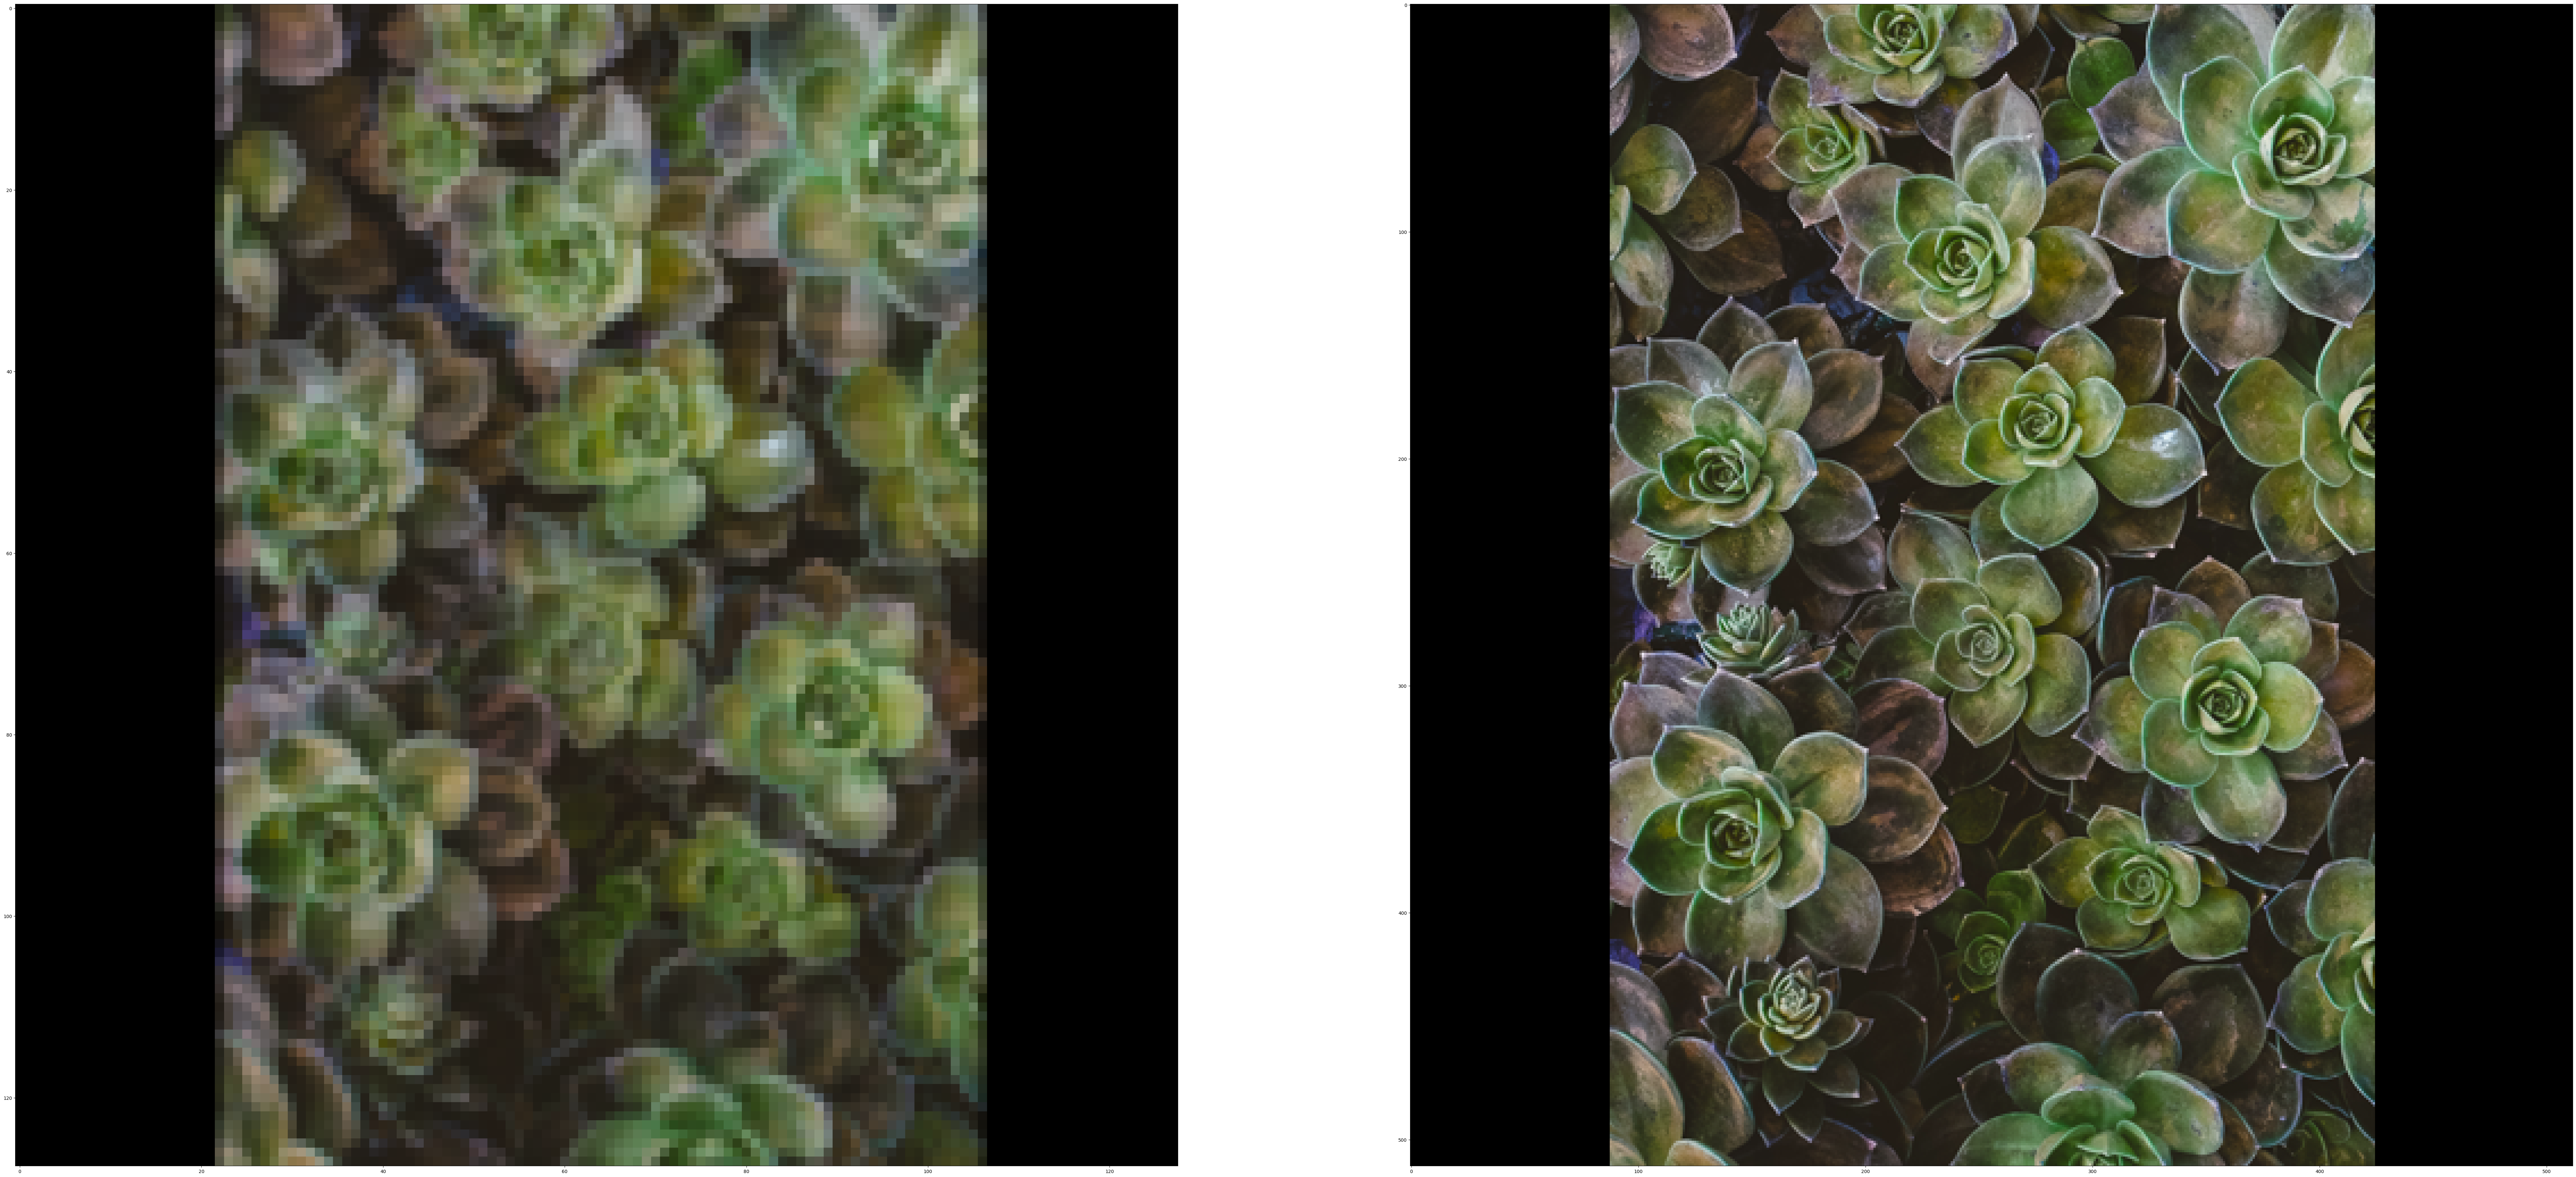

In [7]:
fig = plt.figure(figsize=(100, 100))

fig.add_subplot(1, 2, 1)
plt.imshow(train_tuple[0][0])
fig.add_subplot(1,2, 2)
plt.imshow(train_tuple[0][1])

In [8]:
# from torch.utils.data import Dataset, DataLoader
# class SRDataset(Dataset):
#     def __init__(self, data):
#         self.data = data

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         low_res, high_res = self.data[idx]

#         # Convert BGR to RGB
#         low_res = cv2.cvtColor(low_res, cv2.COLOR_BGR2RGB)
#         high_res = cv2.cvtColor(high_res, cv2.COLOR_BGR2RGB)

#         low_res = torch.from_numpy(low_res)
#         high_res = torch.from_numpy(high_res)

#         return low_res, high_res

# # Create datasets and dataloaders
# train_dataset = SRDataset(train_tuple)
# test_dataset = SRDataset(test_tuple)

# train_dataloader = DataLoader(dataset=train_dataset, batch_size=4, shuffle=True)
# test_dataloader = DataLoader(dataset=test_dataset, batch_size=4, shuffle=False)

In [9]:
from torch.utils.data import Dataset
import cv2
import torch

class SRDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        low_res, high_res = self.data[idx]

        # Convert BGR to RGB
        low_res = cv2.cvtColor(low_res, cv2.COLOR_BGR2RGB)
        high_res = cv2.cvtColor(high_res, cv2.COLOR_BGR2RGB)

        # Convert to float and normalize to [0, 1]
        low_res = low_res.astype('float32') / 255.0
        high_res = high_res.astype('float32') / 255.0

        # Convert to PyTorch tensors in [C, H, W] format
        low_res = torch.from_numpy(low_res).permute(2, 0, 1)
        high_res = torch.from_numpy(high_res).permute(2, 0, 1)

        return low_res, high_res

# Create datasets and dataloaders
train_dataset = SRDataset(train_tuple)
test_dataset = SRDataset(test_tuple)

train_dataloader = DataLoader(dataset=train_dataset, batch_size=4, shuffle=True)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=4, shuffle=False)

In [10]:
train_iterator = iter(train_dataloader)
batch = next(train_iterator)
inputs, labels = batch
print(inputs.shape,labels.shape)

torch.Size([4, 3, 128, 128]) torch.Size([4, 3, 512, 512])


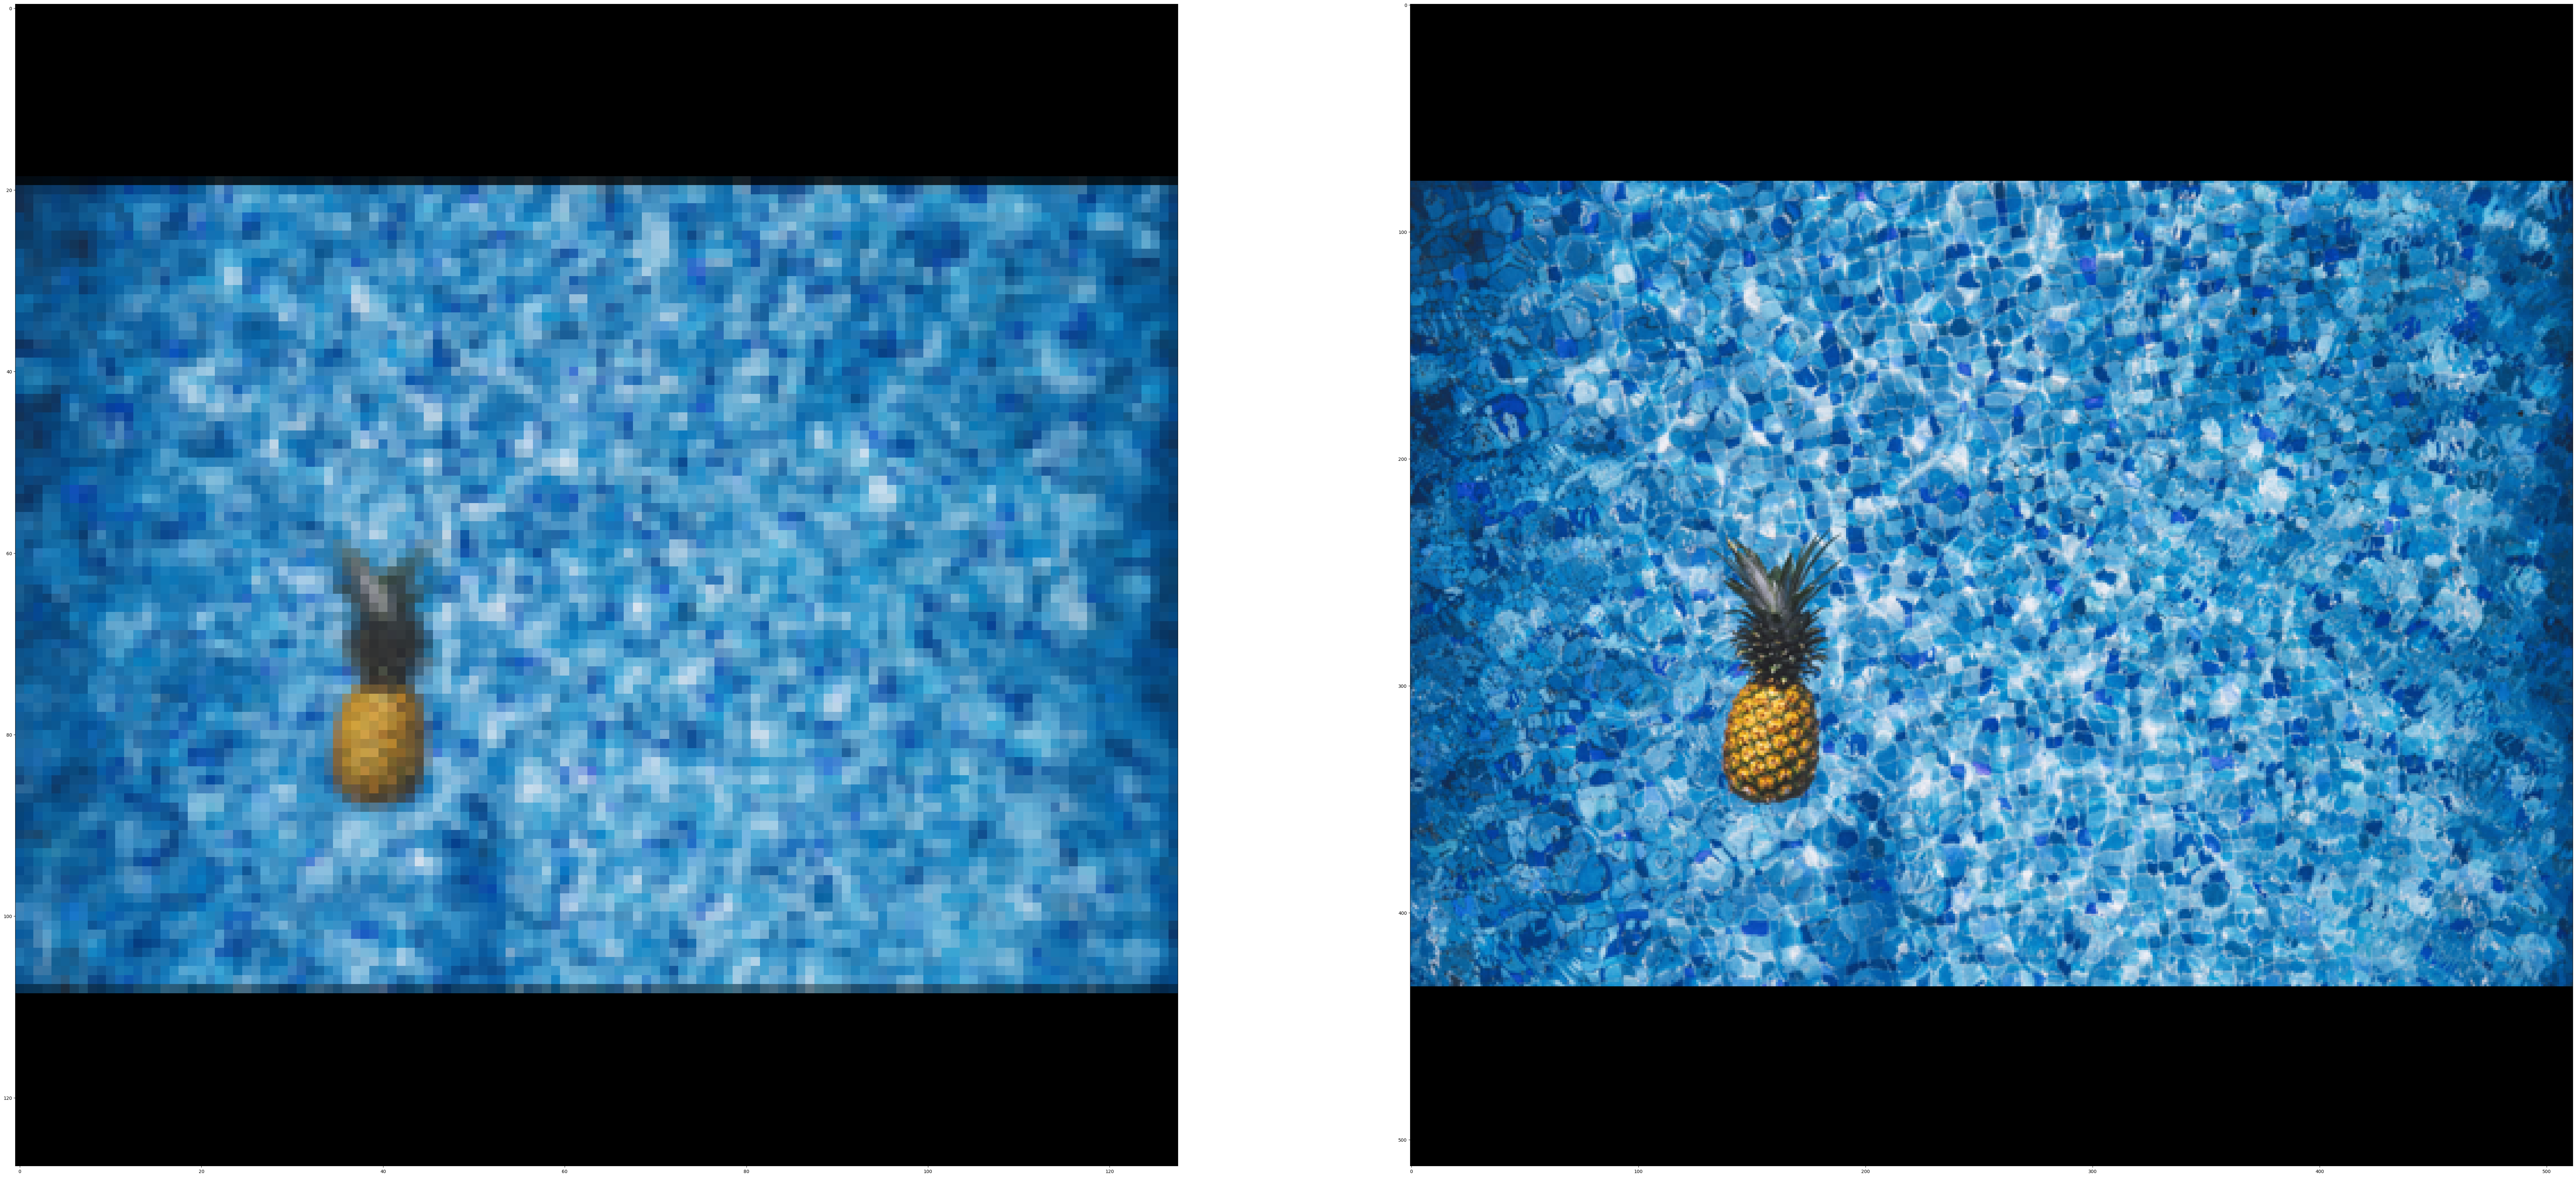

In [11]:
fig = plt.figure(figsize=(100, 100))

fig.add_subplot(1, 2, 1)
plt.imshow(inputs[3].permute(1,2,0).detach().cpu().numpy().astype(np.float32))
fig.add_subplot(1,2, 2)
plt.imshow(labels[3].permute(1,2,0).detach().cpu().numpy().astype(np.float32))

In [ ]:
# class Autoencoder(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.conv1=nn.Conv2d(3, 8, 3, stride=2, padding=1).to(device)
#         self.conv2=nn.Conv2d(8, 16, 3, stride=2, padding=1).to(device)
#         self.conv3=nn.Conv2d(16, 32, 3,stride=2, padding=1).to(device)
#         self.conv4 = nn.Conv2d(32,64,3,stride=2, padding=1).to(device)
#         self.conv5 = nn.Conv2d(64,128,3,stride=2, padding=1).to(device) 
#         self.conv6 = nn.Conv2d(128,256,3,stride=2, padding=1).to(device) 
#         self.conv7 = nn.Conv2d(256,512,3,stride=2, padding=1).to(device) 
        
#         self.conv8 = nn.ConvTranspose2d(512,1024,3,stride=2, padding=1,output_padding=1).to(device)
#         self.conv9 = nn.ConvTranspose2d(1024,512,3,stride=2, padding=1,output_padding=1).to(device)
#         self.conv10 = nn.ConvTranspose2d(512,256,3, stride=2, padding=1, output_padding=1).to(device) 
#         self.conv11= nn.ConvTranspose2d(256,128,3, stride=2, padding=1, output_padding=1).to(device) 
#         self.conv12 = nn.ConvTranspose2d(128,64,3, stride=2, padding=1, output_padding=1).to(device) 
#         self.conv13=nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1).to(device)
#         self.conv14=nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1).to(device) 
#         self.conv15= nn.ConvTranspose2d(16,8,3, stride=2, padding=1, output_padding=1).to(device)
#         self.conv16 = nn.ConvTranspose2d(8,3,3, stride=2, padding=1, output_padding=1).to(device)
        
#         self.relu=nn.ReLU().to(device)

#     def forward(self, x):
#         encoded = self.conv1(x)
#         encoded = self.relu(encoded)

#         encoded = self.conv2(encoded)
#         encoded = self.relu(encoded)

#         encoded = self.conv3(encoded)
#         encoded = self.relu(encoded)

#         encoded = self.conv4(encoded)
#         encoded = self.relu(encoded)

#         encoded = self.conv5(encoded)
#         encoded = self.relu(encoded)

#         encoded = self.conv6(encoded)
#         encoded = self.relu(encoded)

#         encoded = self.conv7(encoded)
#         encoded = self.relu(encoded)

#         decoded = self.conv8(encoded)
#         decoded = self.relu(decoded)

#         decoded = self.conv9(decoded)
#         decoded = self.relu(decoded)

#         decoded = self.conv10(decoded)
#         decoded = self.relu(decoded)

#         decoded = self.conv11(decoded)
#         decoded = self.relu(decoded)

#         decoded = self.conv12(decoded)
#         decoded = self.relu(decoded)

#         decoded = self.conv13(decoded)
#         decoded = self.relu(decoded)

#         decoded = self.conv14(decoded)
#         decoded = self.relu(decoded)

#         decoded = self.conv15(decoded)
#         decoded = self.relu(decoded)
        
#         decoded = self.conv16(decoded)
#         decoded = self.relu(decoded)
#         return decoded

In [12]:
import torch
import torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # ENCODER — compress from 128 -> 64 -> 32
        self.enc1 = nn.Conv2d(3, 64, 3, stride=2, padding=1)   # 128 → 64
        self.enc2 = nn.Conv2d(64, 128, 3, stride=2, padding=1) # 64 → 32

        # DECODER — upsample from 32 → 64 → 128 → 256 → 512
        self.dec1 = nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1)   # 32 → 64
        self.dec2 = nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1)    # 64 → 128
        self.dec3 = nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1)    # 128 → 256
        self.dec4 = nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1)     # 256 → 512

        # Activations
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Encoder
        x = self.relu(self.enc1(x))  # [B, 64, 64, 64]
        x = self.relu(self.enc2(x))  # [B, 128, 32, 32]

        # Decoder
        x = self.relu(self.dec1(x))  # [B, 64, 64, 64]
        x = self.relu(self.dec2(x))  # [B, 32, 128, 128]
        x = self.relu(self.dec3(x))  # [B, 16, 256, 256]
        x = self.sigmoid(self.dec4(x))  # [B, 3, 512, 512]

        return x

In [13]:
model = Autoencoder()
model = nn.DataParallel(model, device_ids=[0, 1])
model.to(device)

criterion = nn.MSELoss()
# criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),
                             lr=1e-3,
                             weight_decay=1e-5)

In [14]:
num_epochs = 100
training_loss = []
testing_loss = []

def train():
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for x, y in train_dataloader:
            x = x.to(device)  # [B, 3, 128, 128]
            y = y.to(device)  # [B, 3, 512, 512]

            recon = model(x)  # Output: [B, 3, 512, 512]
            loss = criterion(recon, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_dataloader)
        training_loss.append(avg_train_loss)
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}")

        # Test every 10 epochs
        if (epoch + 1) % 10 == 0:
            model.eval()
            test_loss = 0.0
            with torch.no_grad():
                for x, y in test_dataloader:
                    x = x.to(device)
                    y = y.to(device)
                    recon = model(x)
                    loss = criterion(recon, y)
                    test_loss += loss.item()

            avg_test_loss = test_loss / len(test_dataloader)
            testing_loss.append(avg_test_loss)
            print(f"→ Test Loss at Epoch {epoch+1}: {avg_test_loss:.4f}")

In [15]:
train()

Epoch 1/100, Train Loss: 0.0388
Epoch 2/100, Train Loss: 0.0135
Epoch 3/100, Train Loss: 0.0107
Epoch 4/100, Train Loss: 0.0081
Epoch 5/100, Train Loss: 0.0074
Epoch 6/100, Train Loss: 0.0071
Epoch 7/100, Train Loss: 0.0068
Epoch 8/100, Train Loss: 0.0065
Epoch 9/100, Train Loss: 0.0063
Epoch 10/100, Train Loss: 0.0061
→ Test Loss at Epoch 10: 0.0050
Epoch 11/100, Train Loss: 0.0060
Epoch 12/100, Train Loss: 0.0059
Epoch 13/100, Train Loss: 0.0058
Epoch 14/100, Train Loss: 0.0057
Epoch 15/100, Train Loss: 0.0056
Epoch 16/100, Train Loss: 0.0055
Epoch 17/100, Train Loss: 0.0055
Epoch 18/100, Train Loss: 0.0052
Epoch 19/100, Train Loss: 0.0049
Epoch 20/100, Train Loss: 0.0050
→ Test Loss at Epoch 20: 0.0041
Epoch 21/100, Train Loss: 0.0047
Epoch 22/100, Train Loss: 0.0047
Epoch 23/100, Train Loss: 0.0046
Epoch 24/100, Train Loss: 0.0044
Epoch 25/100, Train Loss: 0.0046
Epoch 26/100, Train Loss: 0.0044
Epoch 27/100, Train Loss: 0.0044
Epoch 28/100, Train Loss: 0.0043
Epoch 29/100, Train L

In [25]:
state = {
    'epoch': num_epochs,
    'state_dict': model.state_dict(),
    'optimizer': optimizer.state_dict(),
}
filepath = "/kaggle/working/model_auto.pth"
torch.save(state, filepath)

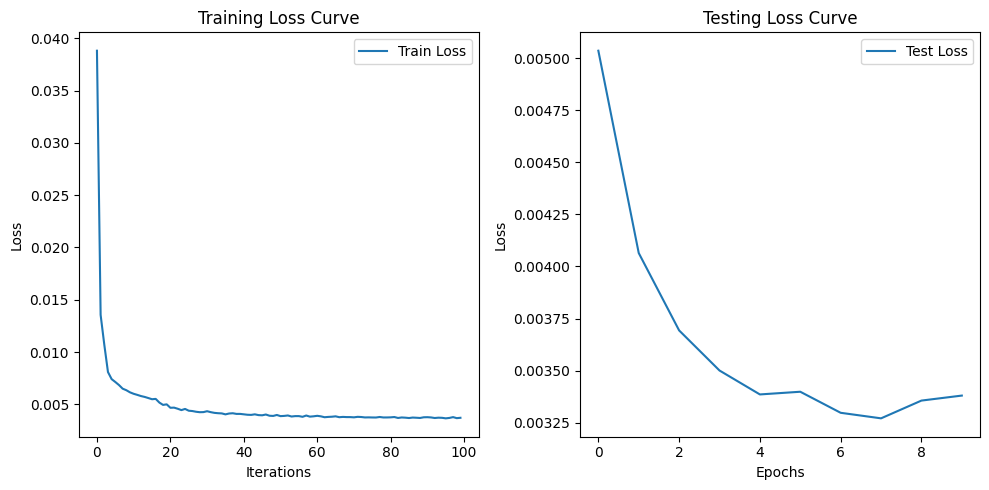

In [27]:
# Plotting
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(len(training_loss)), training_loss, label='Train Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(len(testing_loss)), testing_loss, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Testing Loss Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
def train_result(index):
    x, y = train_tuple[index]

    # Convert BGR to RGB
    x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
    y = cv2.cvtColor(y, cv2.COLOR_BGR2RGB)

    # Convert to float and normalize to [0, 1]
    x = x.astype('float32') / 255.0
    y = y.astype('float32') / 255.0

    # Convert to PyTorch tensors in [C, H, W] format
    x = torch.from_numpy(x).permute(2, 0, 1)
    y = torch.from_numpy(y).permute(2, 0, 1)

    x = x.unsqueeze(dim=0)
    y = y.unsqueeze(dim=0)
    
    model.eval()
    # Train generator
    y_fake = model(x)
    print(y_fake.shape)
    fig = plt.figure(figsize=(80, 80))

    fig.add_subplot(1, 3, 1)
    plt.imshow(x[0].permute(1,2,0).cpu().detach().numpy().astype(np.float32))
    fig.add_subplot(1,3, 2)
    plt.imshow(y[0].permute(1,2,0).cpu().detach().numpy().astype(np.float32))
    fig.add_subplot(1, 3, 3)
    print(y_fake[0].permute(1,2,0).cpu().detach().numpy().shape)
    plt.imshow(y_fake[0].permute(1,2,0).cpu().detach().numpy().astype(np.float32))
    model.train()

torch.Size([1, 3, 512, 512])
(512, 512, 3)


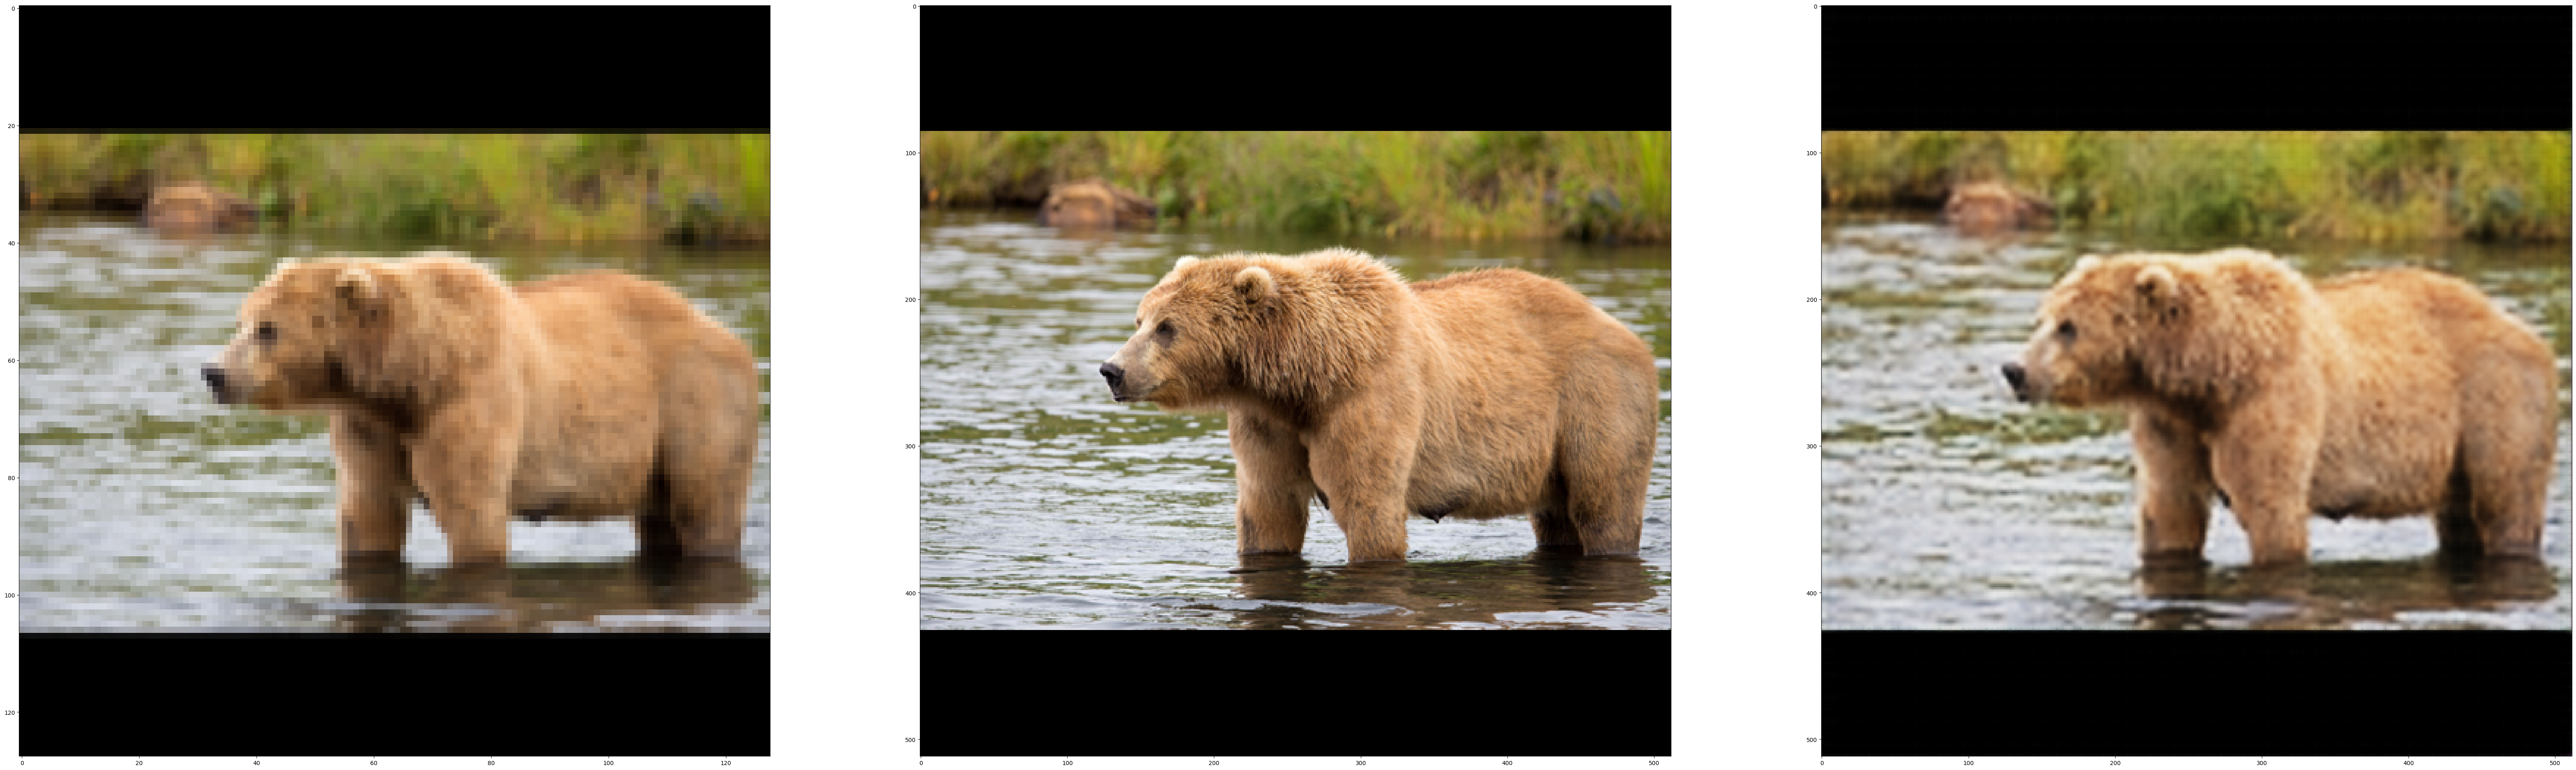

In [28]:
train_result(13)

In [31]:
def test_result(index):
    x, y = test_tuple[index]

    # Convert BGR to RGB
    x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
    y = cv2.cvtColor(y, cv2.COLOR_BGR2RGB)

    # Convert to float and normalize to [0, 1]
    x = x.astype('float32') / 255.0
    y = y.astype('float32') / 255.0

    # Convert to PyTorch tensors in [C, H, W] format
    x = torch.from_numpy(x).permute(2, 0, 1)
    y = torch.from_numpy(y).permute(2, 0, 1)

    x = x.unsqueeze(dim=0)
    y = y.unsqueeze(dim=0)
    
    model.eval()
    # Train generator
    y_fake = model(x)
    print(y_fake.shape)
    fig = plt.figure(figsize=(80, 80))

    fig.add_subplot(1, 3, 1)
    plt.imshow(x[0].permute(1,2,0).cpu().detach().numpy().astype(np.float32))
    fig.add_subplot(1,3, 2)
    plt.imshow(y[0].permute(1,2,0).cpu().detach().numpy().astype(np.float32))
    fig.add_subplot(1, 3, 3)
    print(y_fake[0].permute(1,2,0).cpu().detach().numpy().shape)
    plt.imshow(y_fake[0].permute(1,2,0).cpu().detach().numpy().astype(np.float32))
    model.train()

torch.Size([1, 3, 512, 512])
(512, 512, 3)


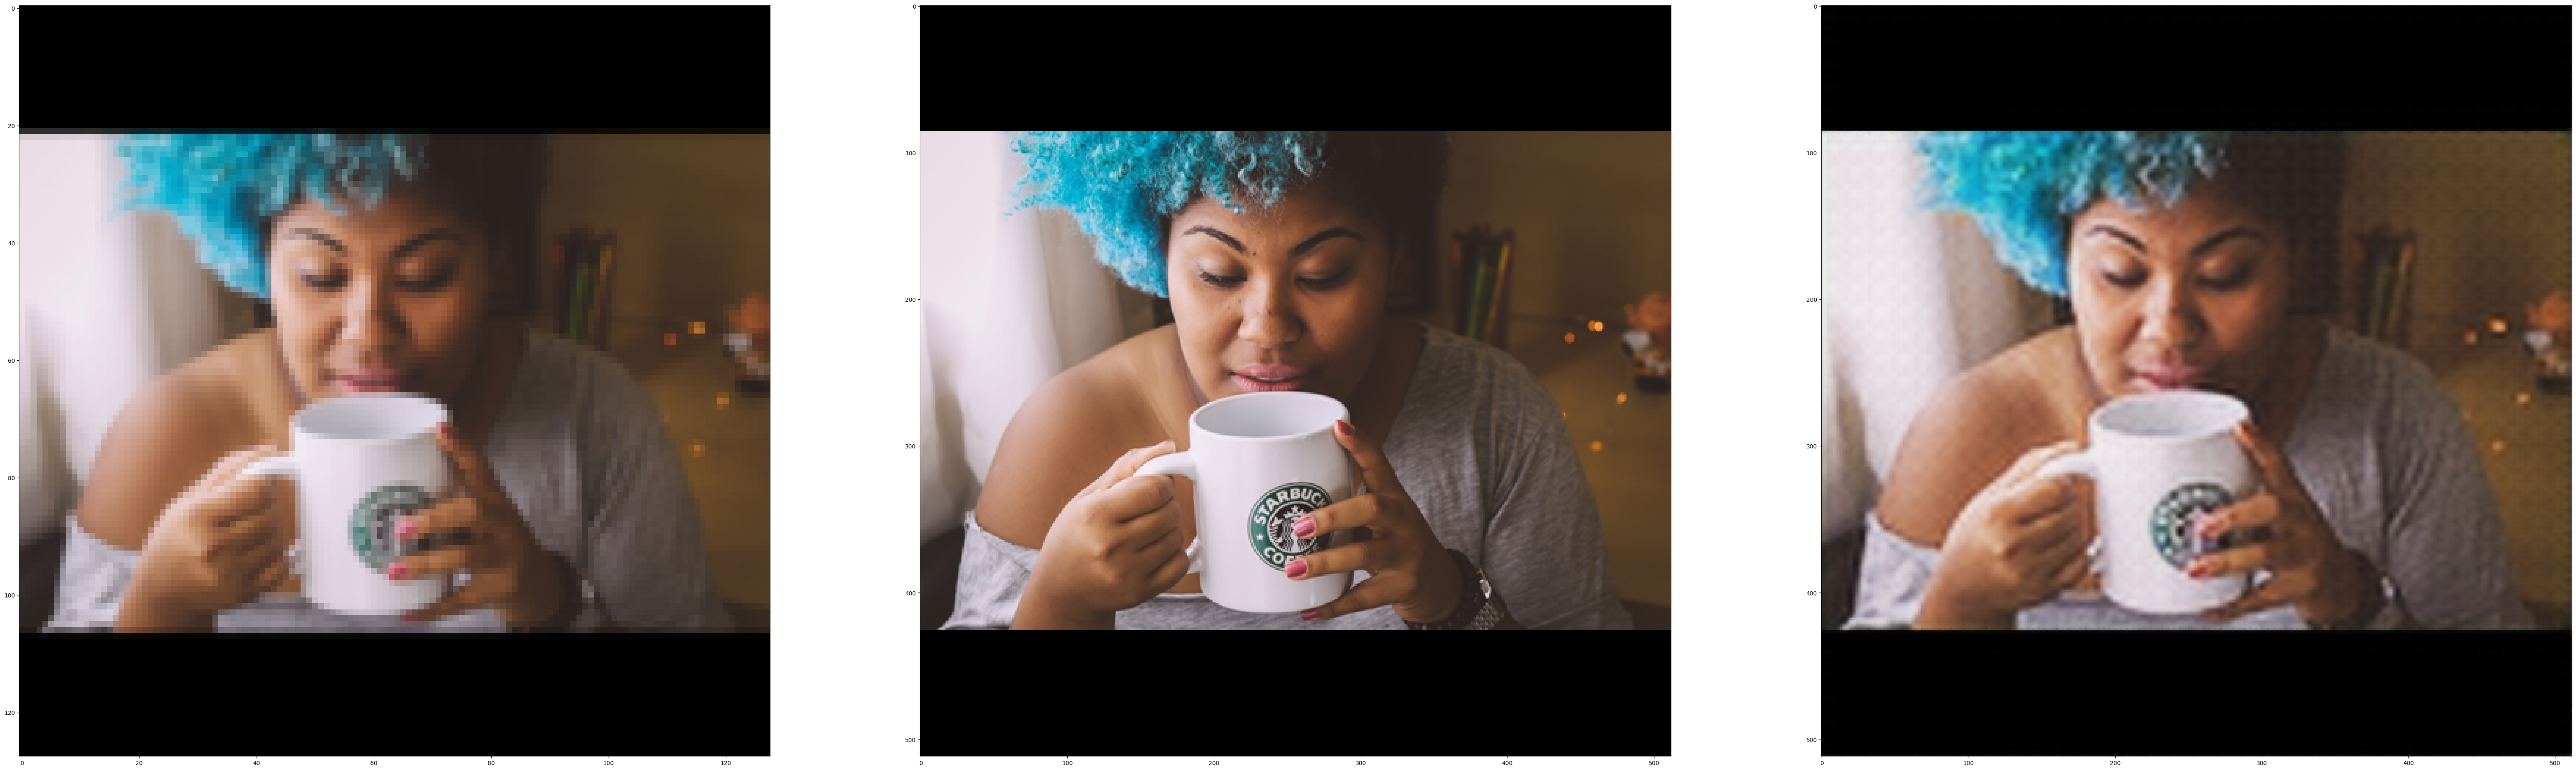

In [33]:
test_result(10)

In [34]:
import torch
import numpy as np
import cv2
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

psnr_list = []
ssim_list = []

model.eval()
for index in range(len(test_tuple)):
    x, y = test_tuple[index]

    # Convert BGR to RGB
    x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
    y = cv2.cvtColor(y, cv2.COLOR_BGR2RGB)

    # Normalize
    x = x.astype('float32') / 255.0
    y = y.astype('float32') / 255.0

    # Convert to PyTorch tensor [C, H, W]
    x_tensor = torch.from_numpy(x).permute(2, 0, 1).unsqueeze(0)
    y_tensor = torch.from_numpy(y).permute(2, 0, 1).unsqueeze(0)

    # Run model
    with torch.no_grad():
        y_fake = model(x_tensor)

    # Convert tensors back to NumPy [H, W, C]
    y_np = y_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    y_fake_np = y_fake.squeeze().permute(1, 2, 0).cpu().numpy()

    # Clip to valid range
    y_np = np.clip(y_np, 0, 1)
    y_fake_np = np.clip(y_fake_np, 0, 1)

    # Compute metrics
    psnr_val = psnr(y_np, y_fake_np, data_range=1.0)
    ssim_val = ssim(y_np, y_fake_np, data_range=1.0, channel_axis=2)

    psnr_list.append(psnr_val)
    ssim_list.append(ssim_val)

# Print average PSNR and SSIM
avg_psnr = sum(psnr_list) / len(psnr_list)
avg_ssim = sum(ssim_list) / len(ssim_list)

print(f"Average PSNR: {avg_psnr:.4f}")
print(f"Average SSIM: {avg_ssim:.4f}")


Average PSNR: 25.3504
Average SSIM: 0.7698
